<a href="https://colab.research.google.com/github/Varsh555/Deep_Learnig/blob/main/Autoencode.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Train shape: (60000, 784)

Training Undercomplete AE...
Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - loss: 0.2341 - val_loss: 0.1497
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 0.1344 - val_loss: 0.1207
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.1165 - val_loss: 0.1104
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.1085 - val_loss: 0.1050
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 0.1041 - val_loss: 0.1008
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.1011 - val_loss: 0.0984
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.0989 - val_loss: 0.0967
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - loss: 0.0970 - val_loss: 0.0951
Epoch 9/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.0955 - val_loss: 0.0940
Epoch 10/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - loss: 0.0943 - val_loss: 0.0926

Training Denoising AE...
Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms

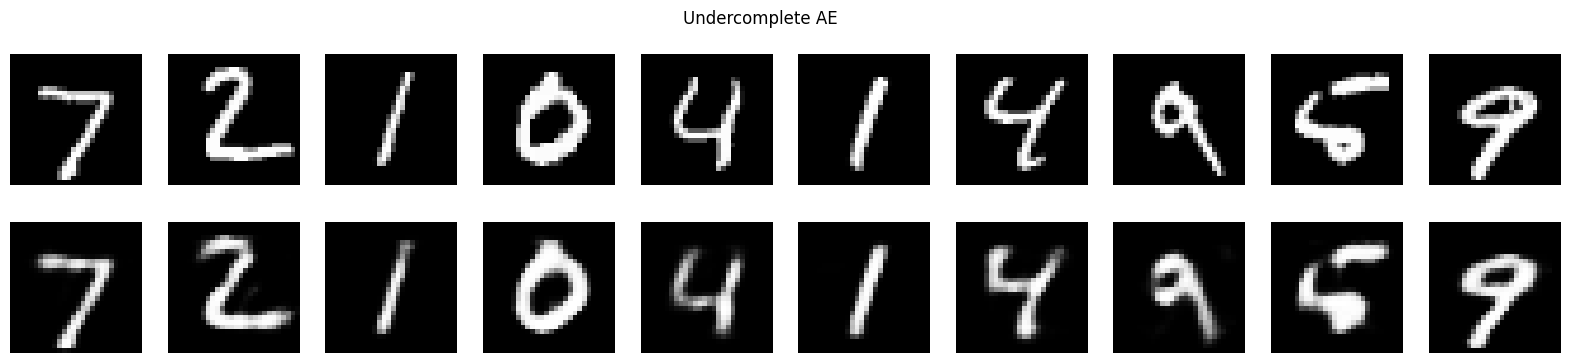

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step


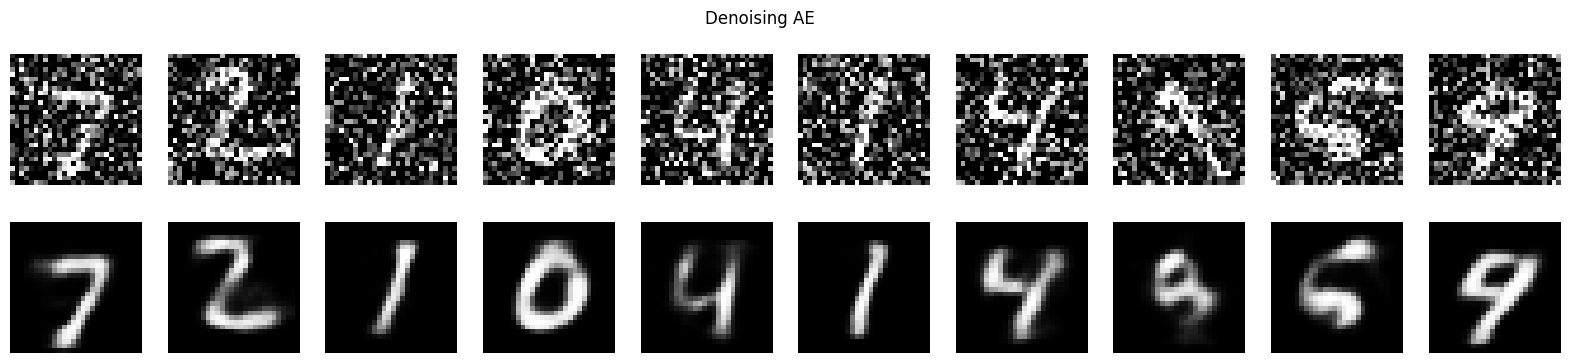

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step


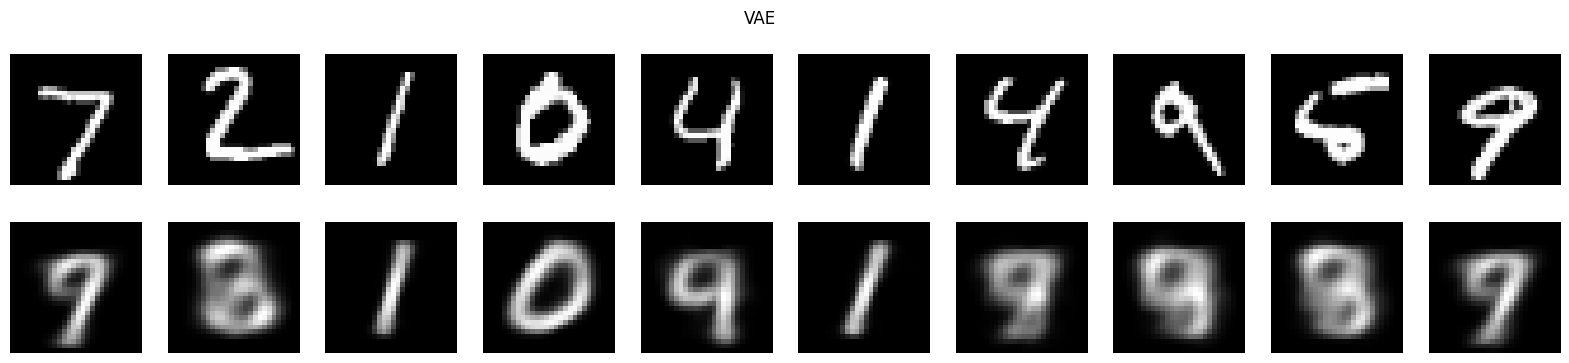

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


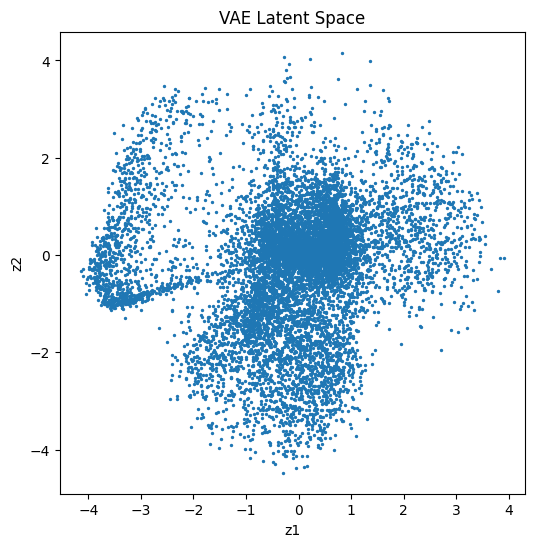

In [3]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt

# =========================================
# 2. Load & preprocess MNIST
# =========================================
(x_train, _), (x_test, _) = mnist.load_data()

x_train = x_train.astype("float32") / 255.
x_test = x_test.astype("float32") / 255.

# Flatten images
x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)

print("Train shape:", x_train.shape)

# =========================================
# 3. UNDERCOMPLETE AUTOENCODER
# =========================================
encoding_dim = 32

inp = layers.Input(shape=(784,))
x = layers.Dense(128, activation="relu")(inp)
encoded = layers.Dense(encoding_dim, activation="relu")(x)

x = layers.Dense(128, activation="relu")(encoded)
decoded = layers.Dense(784, activation="sigmoid")(x)

autoencoder = models.Model(inp, decoded)
autoencoder.compile(optimizer="adam", loss="binary_crossentropy")

print("\nTraining Undercomplete AE...")
autoencoder.fit(
    x_train, x_train,
    epochs=10,
    batch_size=256,
    validation_data=(x_test, x_test),
    verbose=1
)

# =========================================
# 4. DENOISING AUTOENCODER
# =========================================
noise_factor = 0.5

x_train_noisy = x_train + noise_factor * np.random.normal(size=x_train.shape)
x_test_noisy = x_test + noise_factor * np.random.normal(size=x_test.shape)

x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

denoise_ae = models.clone_model(autoencoder)
denoise_ae.compile(optimizer="adam", loss="binary_crossentropy")

print("\nTraining Denoising AE...")
denoise_ae.fit(
    x_train_noisy, x_train,
    epochs=10,
    batch_size=256,
    validation_data=(x_test_noisy, x_test),
    verbose=1
)

# =========================================
# 5. VARIATIONAL AUTOENCODER (FINAL FIXED)
# =========================================
latent_dim = 2

# ----- Encoder -----
encoder_inputs = layers.Input(shape=(784,))
x = layers.Dense(128, activation="relu")(encoder_inputs)
z_mean = layers.Dense(latent_dim)(x)
z_log_var = layers.Dense(latent_dim)(x)

def sampling(z_mean, z_log_var):
    eps = tf.random.normal(shape=(tf.shape(z_mean)[0], latent_dim))
    return z_mean + tf.exp(0.5 * z_log_var) * eps

z = layers.Lambda(lambda t: sampling(t[0], t[1]))([z_mean, z_log_var])

encoder = models.Model(encoder_inputs, [z_mean, z_log_var, z], name="encoder")

# ----- Decoder -----
latent_inputs = layers.Input(shape=(latent_dim,))
x = layers.Dense(128, activation="relu")(latent_inputs)
decoder_outputs = layers.Dense(784, activation="sigmoid")(x)

decoder = models.Model(latent_inputs, decoder_outputs, name="decoder")

# ----- Custom VAE -----
class VAE(models.Model):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def call(self, inputs):
        z_mean, z_log_var, z = self.encoder(inputs)
        return self.decoder(z)

    def compute_loss(self, data):
        z_mean, z_log_var, z = self.encoder(data)
        reconstruction = self.decoder(z)

        # Reconstruction loss
        recon_loss = tf.reduce_mean(
            tf.keras.losses.binary_crossentropy(data, reconstruction)
        ) * 784

        # KL divergence
        kl_loss = -0.5 * tf.reduce_mean(
            tf.reduce_sum(
                1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var),
                axis=1
            )
        )

        total_loss = recon_loss + kl_loss
        return total_loss, recon_loss, kl_loss

    def train_step(self, data):
        if isinstance(data, tuple):
            data = data[0]

        with tf.GradientTape() as tape:
            total_loss, recon_loss, kl_loss = self.compute_loss(data)

        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

        return {
            "loss": total_loss,
            "reconstruction_loss": recon_loss,
            "kl_loss": kl_loss,
        }

    def test_step(self, data):
        if isinstance(data, tuple):
            data = data[0]

        total_loss, recon_loss, kl_loss = self.compute_loss(data)

        return {
            "loss": total_loss,
            "reconstruction_loss": recon_loss,
            "kl_loss": kl_loss,
        }

vae = VAE(encoder, decoder)
vae.compile(optimizer="adam")

print("\nTraining VAE...")
vae.fit(
    x_train,
    epochs=10,
    batch_size=256,
    validation_data=(x_test,),
    verbose=1
)

# =========================================
# 6. Visualization
# =========================================
def plot_results(model, data, title):
    preds = model.predict(data[:10])

    plt.figure(figsize=(20, 4))
    for i in range(10):
        # Original
        ax = plt.subplot(2, 10, i + 1)
        plt.imshow(data[i].reshape(28, 28), cmap="gray")
        plt.axis("off")

        # Reconstructed
        ax = plt.subplot(2, 10, i + 11)
        plt.imshow(preds[i].reshape(28, 28), cmap="gray")
        plt.axis("off")

    plt.suptitle(title)
    plt.show()

print("\nDisplaying results...")

plot_results(autoencoder, x_test, "Undercomplete AE")
plot_results(denoise_ae, x_test_noisy, "Denoising AE")

# VAE prediction wrapper
def vae_predict(x):
    z_mean, z_log_var, z = encoder.predict(x)
    return decoder.predict(z)

plot_results(type("obj", (), {"predict": vae_predict}), x_test, "VAE")

# =========================================
# 7. Latent Space Visualization
# =========================================
z_mean, _, _ = encoder.predict(x_test)

plt.figure(figsize=(6, 6))
plt.scatter(z_mean[:, 0], z_mean[:, 1], s=2)
plt.title("VAE Latent Space")
plt.xlabel("z1")
plt.ylabel("z2")
plt.show()